---

# ASSIGNMENT 7: SCATTERPLOTS AND HISTOGRAMS

---

>---
>
>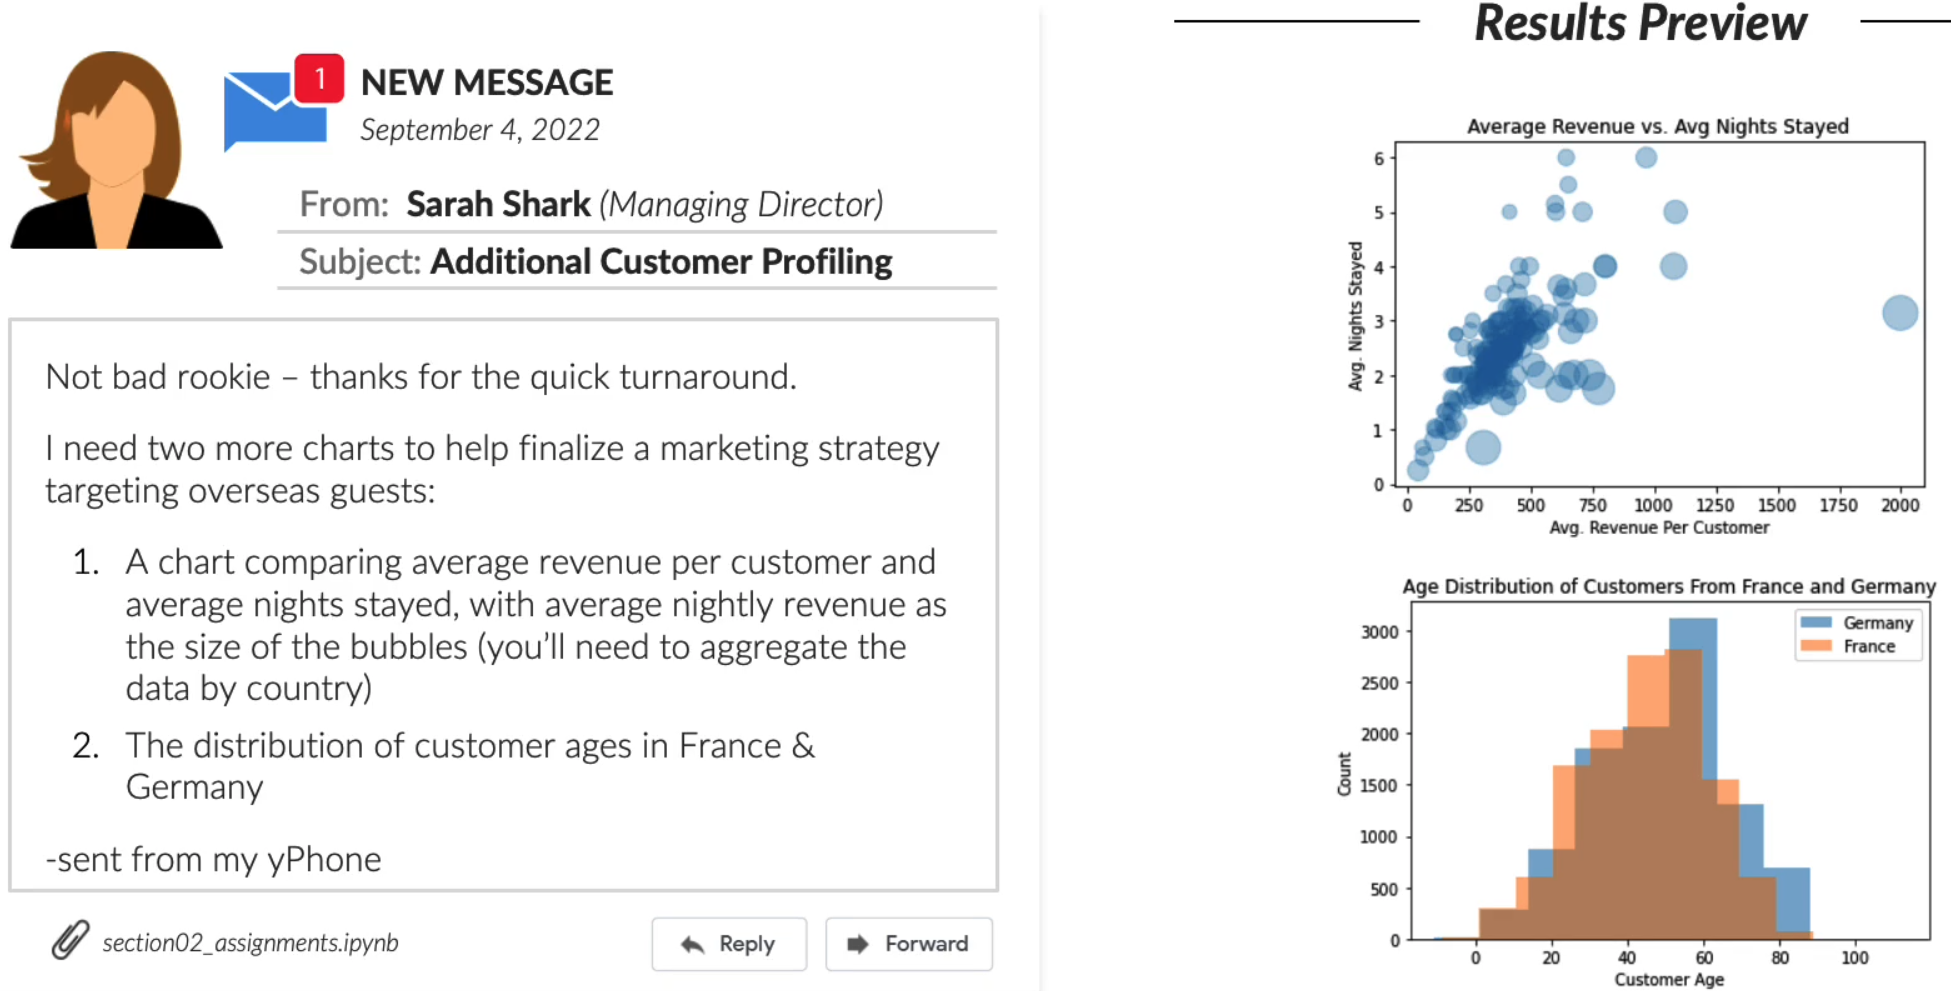
>
>---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel('../Data/HotelCustomersDataset.xlsx').dropna()

# df['date'] = (pd.to_datetime('2018-12-31') - pd.to_timedelta(df.DaysSinceCreation, unit='D')).astype('datetime64[ns]')
df = df[['Nationality', 'Age', 'OtherRevenue', 'LodgingRevenue', 'RoomNights']]

display(df.head(), df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 79811 entries, 0 to 83589
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Nationality     79811 non-null  object 
 1   Age             79811 non-null  float64
 2   OtherRevenue    79811 non-null  float64
 3   LodgingRevenue  79811 non-null  float64
 4   RoomNights      79811 non-null  int64  
dtypes: float64(3), int64(1), object(1)
memory usage: 3.7+ MB


,Nationality,Age,OtherRevenue,LodgingRevenue,RoomNights
0,PRT,51.0,105.3,371.0,5
2,DEU,31.0,0.0,0.0,0
3,FRA,60.0,60.0,240.0,5
4,FRA,51.0,0.0,0.0,0
5,JPN,54.0,24.0,230.0,2


None

In [3]:
df_assign = (df
    .assign(total_revenue = df.LodgingRevenue + df.OtherRevenue,
            revenue_per_night = lambda x: x.total_revenue / x['RoomNights'])
)
df_assign.head()

,Nationality,Age,OtherRevenue,LodgingRevenue,RoomNights,total_revenue,revenue_per_night
0,PRT,51.0,105.3,371.0,5,476.3,95.26
2,DEU,31.0,0.0,0.0,0,0.0,NaN
3,FRA,60.0,60.0,240.0,5,300.0,60.00
4,FRA,51.0,0.0,0.0,0,0.0,NaN
5,JPN,54.0,24.0,230.0,2,254.0,127.00


In [4]:
df_assign = (df_assign
    .groupby('Nationality', as_index=False)
    .agg(total_revenue = ('total_revenue', 'sum'),
         avg_revenue = ('total_revenue', 'mean'),
         avg_age = ('Age', 'mean'),
         avg_nights = ('RoomNights', 'mean'),
         avg_nightly_revenue = ('revenue_per_night', 'mean')
        )
)

df_assign.head()

,Nationality,total_revenue,avg_revenue,avg_age,avg_nights,avg_nightly_revenue
0,ABW,2153.22,717.740000,42.666667,3.666667,204.421111
1,AGO,115174.49,632.826868,41.681319,3.461538,177.745487
2,AIA,1290.10,430.033333,25.666667,1.666667,232.737500
3,ALB,4267.88,328.298462,35.153846,2.846154,118.783788
4,AND,3760.25,537.178571,43.285714,2.000000,283.452381


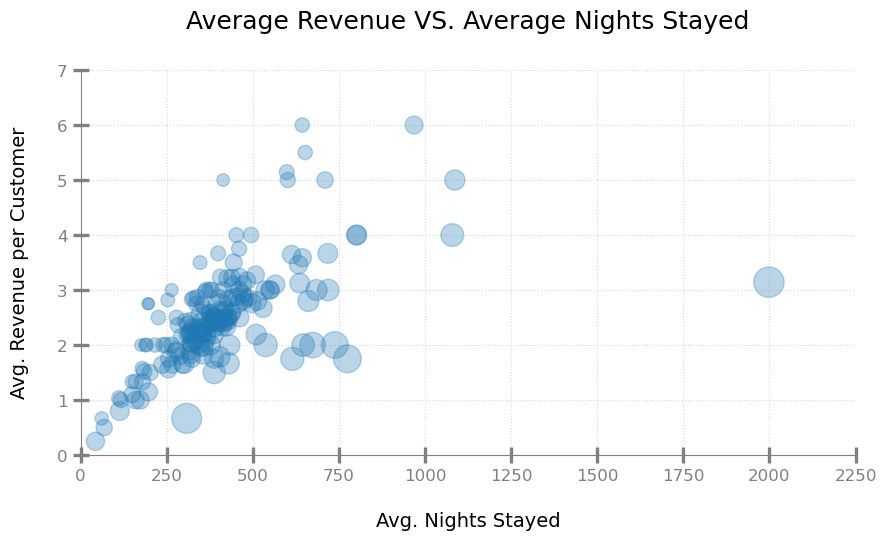

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(df_assign.avg_revenue, df_assign.avg_nights,
           s=df_assign.avg_nightly_revenue, alpha=0.3)
ax.set_xlim(0, 2250)
ax.set_ylim(0, 7)

ax.set_title('Average Revenue VS. Average Nights Stayed', fontsize=18, pad=30)
ax.set_xlabel('Avg. Nights Stayed', fontsize=14, labelpad=20)
ax.set_ylabel('Avg. Revenue per Customer', fontsize=14, labelpad=20)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('gray')
ax.tick_params(axis='both', direction='inout',
               length=12, width=2.4, color='gray',
               colors='gray', labelsize=12)
ax.grid(axis='both', ls=':', c='gray', alpha=0.3)

plt.show()

<br>

---

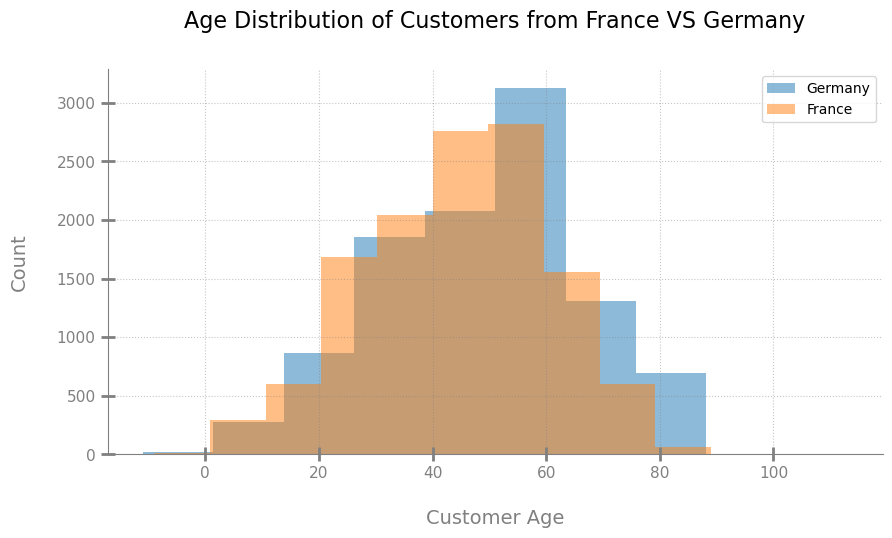

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df.query("Nationality == 'DEU'")['Age'], alpha=0.5, label='Germany')
ax.hist(df.query("Nationality == 'FRA'")['Age'], alpha=0.5, label='France')

ax.set_title('Age Distribution of Customers from France VS Germany', 
             fontsize=16, pad=30)
ax.set_xlabel('Customer Age', fontsize=14, color='gray', labelpad=20)
ax.set_ylabel('Count', fontsize=14, color='gray', labelpad=20)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['bottom', 'left']].set_color('gray')
ax.tick_params(axis='both', direction='inout',
               length=10, width=2, color='gray',
               colors='gray', labelsize=11)
ax.grid(axis='both', linestyle=':', color='gray', alpha=0.45)
ax.legend()

plt.show()